# Lab05 : Thực hành cài đặt thuật toán thỏa mãn ràng buộc
## Bài toán N-Queens (N quân hậu)

**Mô tả:**  
Đặt N quân hậu lên bàn cờ NxN sao cho không có cặp quân hậu nào tấn công nhau
(Bài toán mở rộng của 8-Queens)

**Mục tiêu notebook:**
- Hiểu bài toán N-Queens
- Cài đặt Backtracking
- Cài đặt Heuristic Min-Conflicts
- So sánh hiệu quả giữa hai phương pháp


### Xác định bài toán:  

**Trạng thái:** Bao gồm tập biến: $V = \{v_1,v_2,v_3,...,v_N\}$, trong đó $v_i$ biểu diễn cột của quân hậu tại dòng $i$

**Miền giá trị:** với mỗi $v_i$ có $D(v_i) = \{0,1,2,...,N-1\}$  

**Các ràng buộc chính:** Các quân hậu không tấn công lẫn nhau:
$\forall i\neq j$, (với $i$, $j$ là 2 dòng khác nhau)
+ Ràng buộc hàng: Không có vì mỗi hậu nằm trên một hàng khác nhau
+ Ràng buộc cột: $v_i \neq v_j$
+ Ràng buộc đường chéo chính/phụ: $|v_i-i| \neq |v_j - j|$

### Biểu diễn trạng thái: 

 Biểu diễn trạng thái bàn cờ dưới dạng vị trí hậu của từng dòng

In [ ]:
## Biểu diễn trạng thái bàn cờ dưới dạng vị trí hậu của từng dòng
'''
pos = []
pos[i] = k
Tương ứng với hậu đặt ở dòng i cột k
Cài đặt theo hướng đặt hậu theo từng hàng
## Ta có các ô ko thể đặt nếu đã đặt dòng trước đó một hậu ở (i,j) với k là hằng số ta có:
## Chéo chính: (i+k, j+k), chéo phụ: (i+k, j-k), cột dọc: (i+k, j)
## Tại mỗi ô (x,y) so với (i,j) thì nếu:
## Trùng đường chéo chính: có x = y + k và (x,y) = (i+k,j+k) 
#                                   => x-i = k và y-j = k 
#                                   => x-i = y-j = k
#                                   =>|x-i| = |y-j| = k

## Trùng đường chéo phụ : x = k-y và (x,y) = (i+k,j-k) 
#                                   => x-i = k và y-j = -k <=> |y-j| = k
#                                   => x-i = |y-j| = k
#                                   => |x-i| = |y-j| = k
 
## Suy ra tổng quát: Trùng cả hai chéo: |x-i| = |y-j| = k
## Trùng dọc: chỉ số cột bằng nhau
'''

### Cài đặt backtracking:

#### Giải thuật tổng quát:
```
BACKTRACK(row):
    if row == N:
        return SUCCESS   // đã đặt đủ N quân hậu
    for col = 0 to N-1:
        if isSafe(row, col):
            pos[row] = col
            if BACKTRACK(row + 1) == SUCCESS:
                return SUCCESS
            pos[row] = UNASSIGNED
    return FAILURE

N-QUEENS(N):
    khởi tạo pos[0..N-1] = UNASSIGNED
    BACKTRACK(0)
``` 

In [4]:
import numpy as np

def parseBoard(pos): ## Hàm in bàn cờ từ mảng pos
    N = len(pos)                                ## kích thước pos --> tạo mảng nxn
    board = np.full((N,N),".", dtype='<U3')     ## tạo mảng 2d fill hết là dấu .
    for r, c in enumerate(pos):
        board[r][c] = "Q"                       ## đặt hậu
    for r in range(len(board)):                 ## in bàn cờ
        for c in range(len(board[r])):
            print(f'{board[r][c]}', end=" ")
        print()

In [40]:

def check_valid(row, col, pos):                 ## kiểm tra vùng tấn công
    for i in range(0, row):
        if pos[i] == col: return False          ## kiểm tra trùng cột
        if abs(row - i) == abs(col - pos[i]): return False
    return True

def backtracking(row, N, pos, counter):
    if row == N:
        counter[0] += 1                         ## Đếm số trạng thái đúng (kể cả đối xứng)
        print(f"Way {counter[0]}:")
        parseBoard(pos)                         ## in bàn cờ đúng
        print()
        return 1
    count = 0
    for col in range (0, N):
        if check_valid(row, col, pos):
            pos.append(col)                     ##
            count += backtracking(row+1, N, pos, counter) # đệ quy
            pos.pop()                           # backtracking trả về trạng thái cũ
    return count

def N_Queens(N):
    print(f'Bàn cờ {N}x{N}')
    pos = []                                    ## Tương ứng pos[i] = k (đặt hậu vị trí cột k dòng i)
    counter = [0]
    count = backtracking(0, N, pos, counter)
    print(f'có {count} cách đặt {N} quân hậu không tấn công nhau\n')
    parseBoard(pos)
    

In [41]:
N_Queens(4)
N_Queens(8)

Bàn cờ 4x4
Way 1:
. Q . . 
. . . Q 
Q . . . 
. . Q . 

Way 2:
. . Q . 
Q . . . 
. . . Q 
. Q . . 

có 2 cách đặt 4 quân hậu không tấn công nhau

Bàn cờ 8x8
Way 1:
Q . . . . . . . 
. . . . Q . . . 
. . . . . . . Q 
. . . . . Q . . 
. . Q . . . . . 
. . . . . . Q . 
. Q . . . . . . 
. . . Q . . . . 

Way 2:
Q . . . . . . . 
. . . . . Q . . 
. . . . . . . Q 
. . Q . . . . . 
. . . . . . Q . 
. . . Q . . . . 
. Q . . . . . . 
. . . . Q . . . 

Way 3:
Q . . . . . . . 
. . . . . . Q . 
. . . Q . . . . 
. . . . . Q . . 
. . . . . . . Q 
. Q . . . . . . 
. . . . Q . . . 
. . Q . . . . . 

Way 4:
Q . . . . . . . 
. . . . . . Q . 
. . . . Q . . . 
. . . . . . . Q 
. Q . . . . . . 
. . . Q . . . . 
. . . . . Q . . 
. . Q . . . . . 

Way 5:
. Q . . . . . . 
. . . Q . . . . 
. . . . . Q . . 
. . . . . . . Q 
. . Q . . . . . 
Q . . . . . . . 
. . . . . . Q . 
. . . . Q . . . 

Way 6:
. Q . . . . . . 
. . . . Q . . . 
. . . . . . Q . 
Q . . . . . . . 
. . Q . . . . . 
. . . . . . . Q 
. . . . . Q . .

### Thống kê số nghiệm (kể cả đối xứng) của bàn cờ từ N = 1 đến N = 15

In [48]:
def backtracking_count(row, N, pos):
    if row == N:
        return 1
    count = 0
    for col in range (0, N):
        if check_valid(row, col, pos):
            pos.append(col)                     ##
            count += backtracking_count(row+1, N, pos) # đệ quy
            pos.pop()                           # backtracking trả về trạng thái cũ
    return count

def N_Queens_count(N):
    pos = []                                    ## Tương ứng pos[i] = k (đặt hậu vị trí cột k dòng i)
    counter = [0]
    count = backtracking_count(0, N, pos)
    return count

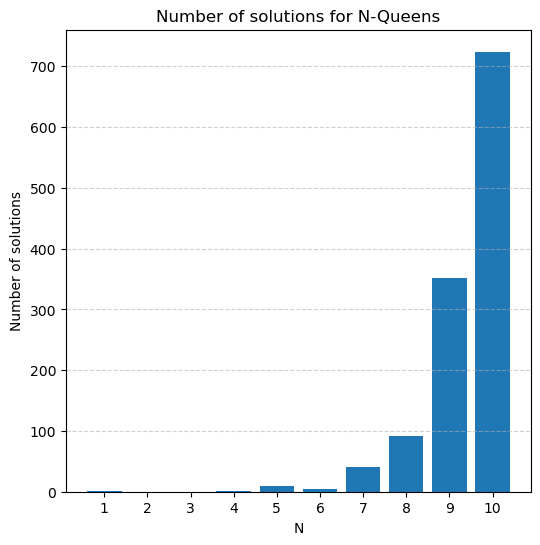

In [53]:
import matplotlib.pyplot as plt

data = []
for i in range(1,11):
    data.append(N_Queens_count(i))


N_values = range(1, 1 + len(data))

plt.figure(figsize=(6, 6))

plt.bar(N_values, data)
plt.xlabel("N")
plt.ylabel("Number of solutions")
plt.title("Number of solutions for N-Queens")

plt.xticks(N_values)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()